# Statistical Analysis: Senescence Association Study

**Module 02: Linear Mixed-Effects Models**

**Study types supported:**
- **Aging cohorts:** Age-associated senescence (continuous variable)
- **Disease cohorts:** Disease-associated senescence (group comparisons)

**Analyses:**
1. Primary association (Age or Diagnosis) with SnC proportion
2. Cell-type-specific effects
3. Sex interactions
4. Cell type composition changes
5. Multiple testing correction

**Statistical approach:**
- Linear Mixed-Effects Models (LMM) with donor random effects
- Adjusts for covariates (age, sex, cohort)
- Cell-type-specific analysis

**Author:** Gerald Gaitos  
**Date:** December 2025

---

## Setup

Import libraries for statistical analysis and visualization.

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Statistical analysis
from scipy import stats
from statsmodels.formula.api import mixedlm
from statsmodels.stats.multitest import multipletests

print(f"scanpy: {sc.__version__}")
print(f"numpy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print("✓ Libraries loaded")

/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


scanpy: 1.11.5
numpy: 2.2.6
pandas: 2.3.3
✓ Libraries loaded


In [2]:
# Figure settings
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'legend.fontsize': 9,
    'font.family': 'sans-serif',
    'axes.linewidth': 1.0,
    'axes.grid': False,
    'pdf.fonttype': 42,
})

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=150, dpi_save=300, facecolor='white', frameon=False)

print("✓ Figure settings configured")

✓ Figure settings configured


---

## Configuration

Set dataset and study type. Must match Module 01 senescence scoring.

In [3]:
# ════════════════════════════════════════════════════════════════════════════════
# DATASET SELECTION
# ════════════════════════════════════════════════════════════════════════════════

DATASET = 'psychad_aging'  # Must match Module 01

# ════════════════════════════════════════════════════════════════════════════════
# STUDY TYPE CONFIGURATION
# ════════════════════════════════════════════════════════════════════════════════

STUDY_CONFIG = {
    'psychad_aging': {
        'type': 'aging',
        'primary_var': 'Age',                    # Continuous age variable
        'primary_var_type': 'continuous',
        'covariates': ['Sex', 'Cohort'],         
        'random_effect': 'Sample',               # Donor ID for random effects
    },
    'psychad_ad': {
        'type': 'disease',
        'primary_var': 'Study_Group',            # Categorical diagnosis
        'primary_var_type': 'categorical',
        'reference_group': 'Control',            # Reference for comparisons
        'covariates': ['Age', 'Sex', 'Cohort'],  
        'random_effect': 'Sample',
    },
    'psychencode': {
        'type': 'aging',
        'primary_var': 'Age',
        'primary_var_type': 'continuous',
        'covariates': ['Sex', 'Cohort'],         
        'random_effect': 'Sample',
    },
}

config = STUDY_CONFIG[DATASET]
STUDY_TYPE = config['type']
PRIMARY_VAR = config['primary_var']
PRIMARY_VAR_TYPE = config['primary_var_type']
COVARIATES = config['covariates']
RANDOM_EFFECT = config['random_effect']

# Column names
CELL_TYPE_COLUMN = 'subclass'
SENESCENCE_COLUMN = 'is_senescent'
STUDY_GROUP_COLUMN = 'Study_Group'

# Paths
BASE_DIR = Path('/fs/scratch/PAS2598/senescence_analysis')
INPUT_FILE = BASE_DIR / 'data' / 'processed' / f'{DATASET}_senescence_scored.h5ad'
RESULTS_DIR = BASE_DIR / 'results' / '02_statistical_analysis' / DATASET
FIGURES_DIR = BASE_DIR / 'figures' / '02_statistical_analysis' / DATASET
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("="*80)
print(f"Dataset: {DATASET}")
print(f"Study type: {STUDY_TYPE}")
print(f"Primary variable: {PRIMARY_VAR} ({PRIMARY_VAR_TYPE})")
print(f"Covariates: {', '.join(COVARIATES)}")
print(f"Random effect: {RANDOM_EFFECT}")
print(f"Input: {INPUT_FILE.name}")
print(f"Results: {RESULTS_DIR}")
print(f"Figures: {FIGURES_DIR}")
print("="*80)

Dataset: psychad_aging
Study type: aging
Primary variable: Age (continuous)
Covariates: Sex, Cohort
Random effect: Sample
Input: psychad_aging_senescence_scored.h5ad
Results: /fs/scratch/PAS2598/senescence_analysis/results/02_statistical_analysis/psychad_aging
Figures: /fs/scratch/PAS2598/senescence_analysis/figures/02_statistical_analysis/psychad_aging


---

## Load Data

Load senescence-scored data from Module 01.

In [4]:
print("\n" + "="*80)
print("LOADING DATA")
print("="*80)

adata = sc.read_h5ad(INPUT_FILE)

print(f"\nLoaded: {INPUT_FILE.name}")
print(f"  Cells: {adata.n_obs:,}")
print(f"  Genes: {adata.n_vars:,}")
print(f"  SnC cells: {adata.obs[SENESCENCE_COLUMN].sum():,} ({adata.obs[SENESCENCE_COLUMN].sum()/adata.n_obs*100:.1f}%)")

# Verify required columns
required_cols = [CELL_TYPE_COLUMN, SENESCENCE_COLUMN, PRIMARY_VAR, RANDOM_EFFECT] + COVARIATES
if STUDY_GROUP_COLUMN not in adata.obs.columns:
    required_cols.remove(STUDY_GROUP_COLUMN) if STUDY_GROUP_COLUMN in required_cols else None

missing_cols = [col for col in required_cols if col not in adata.obs.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

print(f"\n✓ All required columns present")

# Show distribution
if PRIMARY_VAR_TYPE == 'continuous':
    print(f"\n{PRIMARY_VAR} distribution:")
    print(f"  Range: {adata.obs[PRIMARY_VAR].min():.1f} - {adata.obs[PRIMARY_VAR].max():.1f}")
    print(f"  Mean: {adata.obs[PRIMARY_VAR].mean():.1f}")
    print(f"  Median: {adata.obs[PRIMARY_VAR].median():.1f}")
else:
    print(f"\n{PRIMARY_VAR} distribution:")
    for group, count in adata.obs[PRIMARY_VAR].value_counts().items():
        print(f"  {group}: {count:,} cells")

print(f"\nCell types: {adata.obs[CELL_TYPE_COLUMN].nunique()}")
print(f"Donors: {adata.obs[RANDOM_EFFECT].nunique()}")

print("\n✓ Data loaded")


LOADING DATA

Loaded: psychad_aging_senescence_scored.h5ad
  Cells: 444,080
  Genes: 34,889
  SnC cells: 21,196 (4.8%)

✓ All required columns present

Age distribution:
  Range: 20.0 - 90.0
  Mean: 54.6
  Median: 55.0

Cell types: 12
Donors: 124

✓ Data loaded


---

## Data Aggregation

Aggregate to donor level: calculate SnC proportion per donor × cell type.

**Why aggregate:** LMM requires donor-level data (not 444K individual cells).

In [5]:
print("\n" + "="*80)
print("DATA AGGREGATION")
print("="*80)

print(f"\nAggregating to donor × cell type level...")

# Calculate SnC proportion per donor × cell type
aggregated_data = []

for donor in adata.obs[RANDOM_EFFECT].unique():
    donor_mask = adata.obs[RANDOM_EFFECT] == donor
    donor_data = adata.obs[donor_mask]
    
    # Get donor-level covariates (should be constant per donor)
    donor_age = donor_data[PRIMARY_VAR].iloc[0] if PRIMARY_VAR_TYPE == 'continuous' else donor_data[PRIMARY_VAR].mode()[0]
    donor_study_group = donor_data[STUDY_GROUP_COLUMN].iloc[0]  # Add Study_Group!
    donor_covariates = {cov: donor_data[cov].iloc[0] for cov in COVARIATES}
    
    # Calculate per cell type
    for cell_type in donor_data[CELL_TYPE_COLUMN].unique():
        ct_mask = donor_data[CELL_TYPE_COLUMN] == cell_type
        ct_cells = donor_data[ct_mask]
        
        n_total = len(ct_cells)
        n_snc = ct_cells[SENESCENCE_COLUMN].sum()
        snc_prop = (n_snc / n_total * 100) if n_total > 0 else 0
        
        row = {
            'Donor': donor,
            'Cell_Type': cell_type,
            'n_cells': n_total,
            'n_SnC': n_snc,
            'SnC_proportion': snc_prop,
            PRIMARY_VAR: donor_age,
            STUDY_GROUP_COLUMN: donor_study_group,  # Add Study_Group!
        }
        row.update(donor_covariates)
        aggregated_data.append(row)

df_agg = pd.DataFrame(aggregated_data)

print(f"\n✓ Aggregation complete")
print(f"  Total observations: {len(df_agg):,} (donor × cell type)")
print(f"  Donors: {df_agg['Donor'].nunique()}")
print(f"  Cell types: {df_agg['Cell_Type'].nunique()}")

# Show summary
print(f"\nSnC proportion summary by cell type:")
summary = df_agg.groupby('Cell_Type')['SnC_proportion'].agg(['mean', 'std', 'min', 'max'])
for ct, row in summary.iterrows():
    print(f"  {ct}: {row['mean']:.2f}% ± {row['std']:.2f}% (range: {row['min']:.2f}-{row['max']:.2f}%)")

print("\n✓ Data ready for statistical analysis")


DATA AGGREGATION

Aggregating to donor × cell type level...

✓ Aggregation complete
  Total observations: 1,419 (donor × cell type)
  Donors: 124
  Cell types: 12

SnC proportion summary by cell type:
  Adaptive: 11.12% ± 18.31% (range: 0.00-66.67%)
  Astrocyte: 10.60% ± 11.89% (range: 0.00-53.41%)
  Endothelial: 10.48% ± 13.97% (range: 0.00-100.00%)
  Excitatory: 1.38% ± 1.84% (range: 0.00-10.77%)
  Inhibitory: 0.48% ± 0.88% (range: 0.00-7.56%)
  Microglia: 11.54% ± 13.65% (range: 0.00-58.24%)
  OPC: 10.46% ± 13.73% (range: 0.00-77.14%)
  Oligodendrocyte: 4.12% ± 6.79% (range: 0.00-55.56%)
  PVM: 8.94% ± 13.95% (range: 0.00-66.67%)
  Pericyte: 13.48% ± 20.22% (range: 0.00-100.00%)
  VLMC: 8.00% ± 14.13% (range: 0.00-66.67%)
  VSMC: 9.63% ± 21.19% (range: 0.00-100.00%)

✓ Data ready for statistical analysis


---

## Linear Mixed-Effects Models

Test association between primary variable and SnC proportion per cell type.

**Model:** SnC_proportion ~ Age + Sex + Cohort + (1|Donor)  
**Random effect:** Accounts for repeated measures (multiple cell types per donor)

In [6]:
print("\n" + "="*80)
print("LINEAR MIXED-EFFECTS MODELS")
print("="*80)

# Build model formula
if PRIMARY_VAR_TYPE == 'continuous':
    formula = f"SnC_proportion ~ {PRIMARY_VAR}"
    if COVARIATES:
        formula += " + " + " + ".join(COVARIATES)
    print(f"\nFormula: {formula} + (1|Donor)")
    print(f"Testing: {PRIMARY_VAR} effect on SnC proportion")
else:
    formula = f"SnC_proportion ~ C({PRIMARY_VAR})"
    if COVARIATES:
        formula += " + " + " + ".join(COVARIATES)
    print(f"\nFormula: {formula} + (1|Donor)")
    print(f"Testing: Group differences in SnC proportion")

# Run LMM for each cell type
print(f"\nRunning LMM per cell type...")
lmm_results = []

for cell_type in sorted(df_agg['Cell_Type'].unique()):
    ct_data = df_agg[df_agg['Cell_Type'] == cell_type].copy()
    
    # Skip if insufficient data
    if len(ct_data) < 10:
        print(f"  {cell_type}: Skipped (n={len(ct_data)})")
        continue
    
    try:
        # Fit LMM
        model = mixedlm(formula, ct_data, groups=ct_data['Donor'])
        result = model.fit(reml=False)
        
        # Extract results for primary variable
        if PRIMARY_VAR_TYPE == 'continuous':
            coef = result.params[PRIMARY_VAR]
            se = result.bse[PRIMARY_VAR]
            pval = result.pvalues[PRIMARY_VAR]
            ci_lower = result.conf_int().loc[PRIMARY_VAR, 0]
            ci_upper = result.conf_int().loc[PRIMARY_VAR, 1]
        else:
            # For categorical, get first contrast (e.g., AD vs Control)
            param_name = [p for p in result.params.index if PRIMARY_VAR in p][0]
            coef = result.params[param_name]
            se = result.bse[param_name]
            pval = result.pvalues[param_name]
            ci_lower = result.conf_int().loc[param_name, 0]
            ci_upper = result.conf_int().loc[param_name, 1]
        
        lmm_results.append({
            'Cell_Type': cell_type,
            'n_obs': len(ct_data),
            'n_donors': ct_data['Donor'].nunique(),
            'Coefficient': coef,
            'SE': se,
            'CI_lower': ci_lower,
            'CI_upper': ci_upper,
            'P_value': pval,
        })
        
        print(f"  {cell_type}: β={coef:.4f}, SE={se:.4f}, p={pval:.2e}")
        
    except Exception as e:
        print(f"  {cell_type}: Failed ({str(e)[:50]})")

# Convert to DataFrame
df_lmm = pd.DataFrame(lmm_results)

# Multiple testing correction
if len(df_lmm) > 0:
    df_lmm['P_adj'] = multipletests(df_lmm['P_value'], method='fdr_bh')[1]
    df_lmm['Significant'] = df_lmm['P_adj'] < 0.05
    
    print(f"\n✓ LMM analysis complete")
    print(f"\nSignificant associations (FDR < 0.05):")
    sig_results = df_lmm[df_lmm['Significant']].sort_values('P_adj')
    if len(sig_results) > 0:
        for _, row in sig_results.iterrows():
            print(f"  {row['Cell_Type']}: β={row['Coefficient']:.4f}, p_adj={row['P_adj']:.2e}")
    else:
        print("  None")

print("\n✓ Statistical analysis complete")


LINEAR MIXED-EFFECTS MODELS

Formula: SnC_proportion ~ Age + Sex + Cohort + (1|Donor)
Testing: Age effect on SnC proportion

Running LMM per cell type...
  Adaptive: β=-0.0440, SE=0.0769, p=5.68e-01
  Astrocyte: β=0.0643, SE=0.0151, p=2.04e-05
  Endothelial: β=0.0402, SE=0.0698, p=5.65e-01
  Excitatory: β=0.0050, SE=0.0024, p=3.84e-02


/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not 

  Inhibitory: β=0.0024, SE=0.0023, p=2.93e-01
  Microglia: β=0.1412, SE=0.0576, p=1.43e-02
  OPC: β=0.1267, SE=0.0280, p=5.83e-06
  Oligodendrocyte: β=0.0032, SE=0.0154, p=8.34e-01
  PVM: β=0.1307, SE=0.0408, p=1.37e-03


/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not 

  Pericyte: β=0.1358, SE=0.0407, p=8.42e-04
  VLMC: β=0.0242, SE=0.0561, p=6.67e-01
  VSMC: β=0.1869, SE=0.0596, p=1.72e-03

✓ LMM analysis complete

Significant associations (FDR < 0.05):
  OPC: β=0.1267, p_adj=6.99e-05
  Astrocyte: β=0.0643, p_adj=1.22e-04
  Pericyte: β=0.1358, p_adj=3.37e-03
  PVM: β=0.1307, p_adj=4.10e-03
  VSMC: β=0.1869, p_adj=4.12e-03
  Microglia: β=0.1412, p_adj=2.85e-02

✓ Statistical analysis complete


/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [7]:
# ════════════════════════════════════════════════════════════════════════════════
# COLOR CONFIGURATION (consistent across all modules)
# ════════════════════════════════════════════════════════════════════════════════

# Study_Group colors (priority for mixed plots)
# Aging: Sequential cool → warm representing age progression (YOUR ORIGINAL PALETTE)
STUDY_GROUP_COLORS = {
    'Age_20_29': '#2E86AB',   # Deep blue (youngest)
    'Age_30_39': '#4A90E2',   # Blue
    'Age_40_49': '#50C878',   # Green
    'Age_50_59': '#FFB347',   # Light orange
    'Age_60_69': '#FF8C00',   # Orange
    'Age_70_79': '#E24A4A',   # Red
    'Age_80_100': '#8B0000',  # Dark red (oldest)
    # Disease cohorts
    'Control': '#4E79A7',     # Blue (neutral)
    'MCI': '#F28E2B',         # Orange (intermediate)
    'AD': '#E15759',          # Red (disease)
    'NCI': '#4E79A7',         # No Cognitive Impairment (like Control)
}

# Cell type colors (for cell-type-focused plots)
CELL_TYPE_COLORS = {
    'Excitatory': '#4E79A7',      # Blue
    'Inhibitory': '#F28E2B',      # Orange
    'Astrocyte': '#E15759',       # Red
    'Oligodendrocyte': '#76B7B2', # Teal
    'OPC': '#59A14F',             # Green
    'Microglia': '#EDC948',       # Yellow
    'Endothelial': '#B07AA1',     # Purple
    'Pericyte': '#FF9DA7',        # Pink
    'VSMC': '#9C755F',            # Brown
    'VLMC': '#BAB0AC',            # Gray
    'PVM': '#D37295',             # Mauve
    'Adaptive': '#FABFD2',        # Light pink
}

print("✓ Color palettes configured")
print(f"  Study_Group colors: {len([k for k in STUDY_GROUP_COLORS if k in adata.obs[STUDY_GROUP_COLUMN].unique()])} defined")
print(f"  Cell_Type colors: {len(CELL_TYPE_COLORS)} defined")

✓ Color palettes configured
  Study_Group colors: 7 defined
  Cell_Type colors: 12 defined


---

## Save Results

Save statistical results table.

In [8]:
print("\n" + "="*80)
print("SAVING RESULTS")
print("="*80)

# Save LMM results
results_file = RESULTS_DIR / f'{DATASET}_lmm_results.csv'
df_lmm.to_csv(results_file, index=False)
print(f"\n✓ Results saved: {results_file.name}")

# Print formatted table
print(f"\nLMM Results Summary:")
print(df_lmm.sort_values('P_adj')[['Cell_Type', 'n_donors', 'Coefficient', 'SE', 'P_value', 'P_adj', 'Significant']].to_string(index=False))


SAVING RESULTS

✓ Results saved: psychad_aging_lmm_results.csv

LMM Results Summary:
      Cell_Type  n_donors  Coefficient       SE  P_value    P_adj  Significant
            OPC       124     0.126702 0.027954 0.000006 0.000070         True
      Astrocyte       124     0.064282 0.015088 0.000020 0.000122         True
       Pericyte       123     0.135796 0.040675 0.000842 0.003369         True
            PVM       110     0.130695 0.040818 0.001365 0.004096         True
           VSMC        98     0.186916 0.059615 0.001716 0.004119         True
      Microglia       124     0.141153 0.057597 0.014259 0.028517         True
     Excitatory       123     0.004999 0.002415 0.038447 0.065908        False
     Inhibitory       124     0.002422 0.002303 0.292909 0.439363        False
       Adaptive       102    -0.043959 0.076931 0.567726 0.681271        False
    Endothelial       123     0.040176 0.069775 0.564754 0.681271        False
           VLMC       120     0.024153 0.0560

---

## Visualizations

Generate forest plot and trajectory plots showing age-associated/disease-associated senescence.

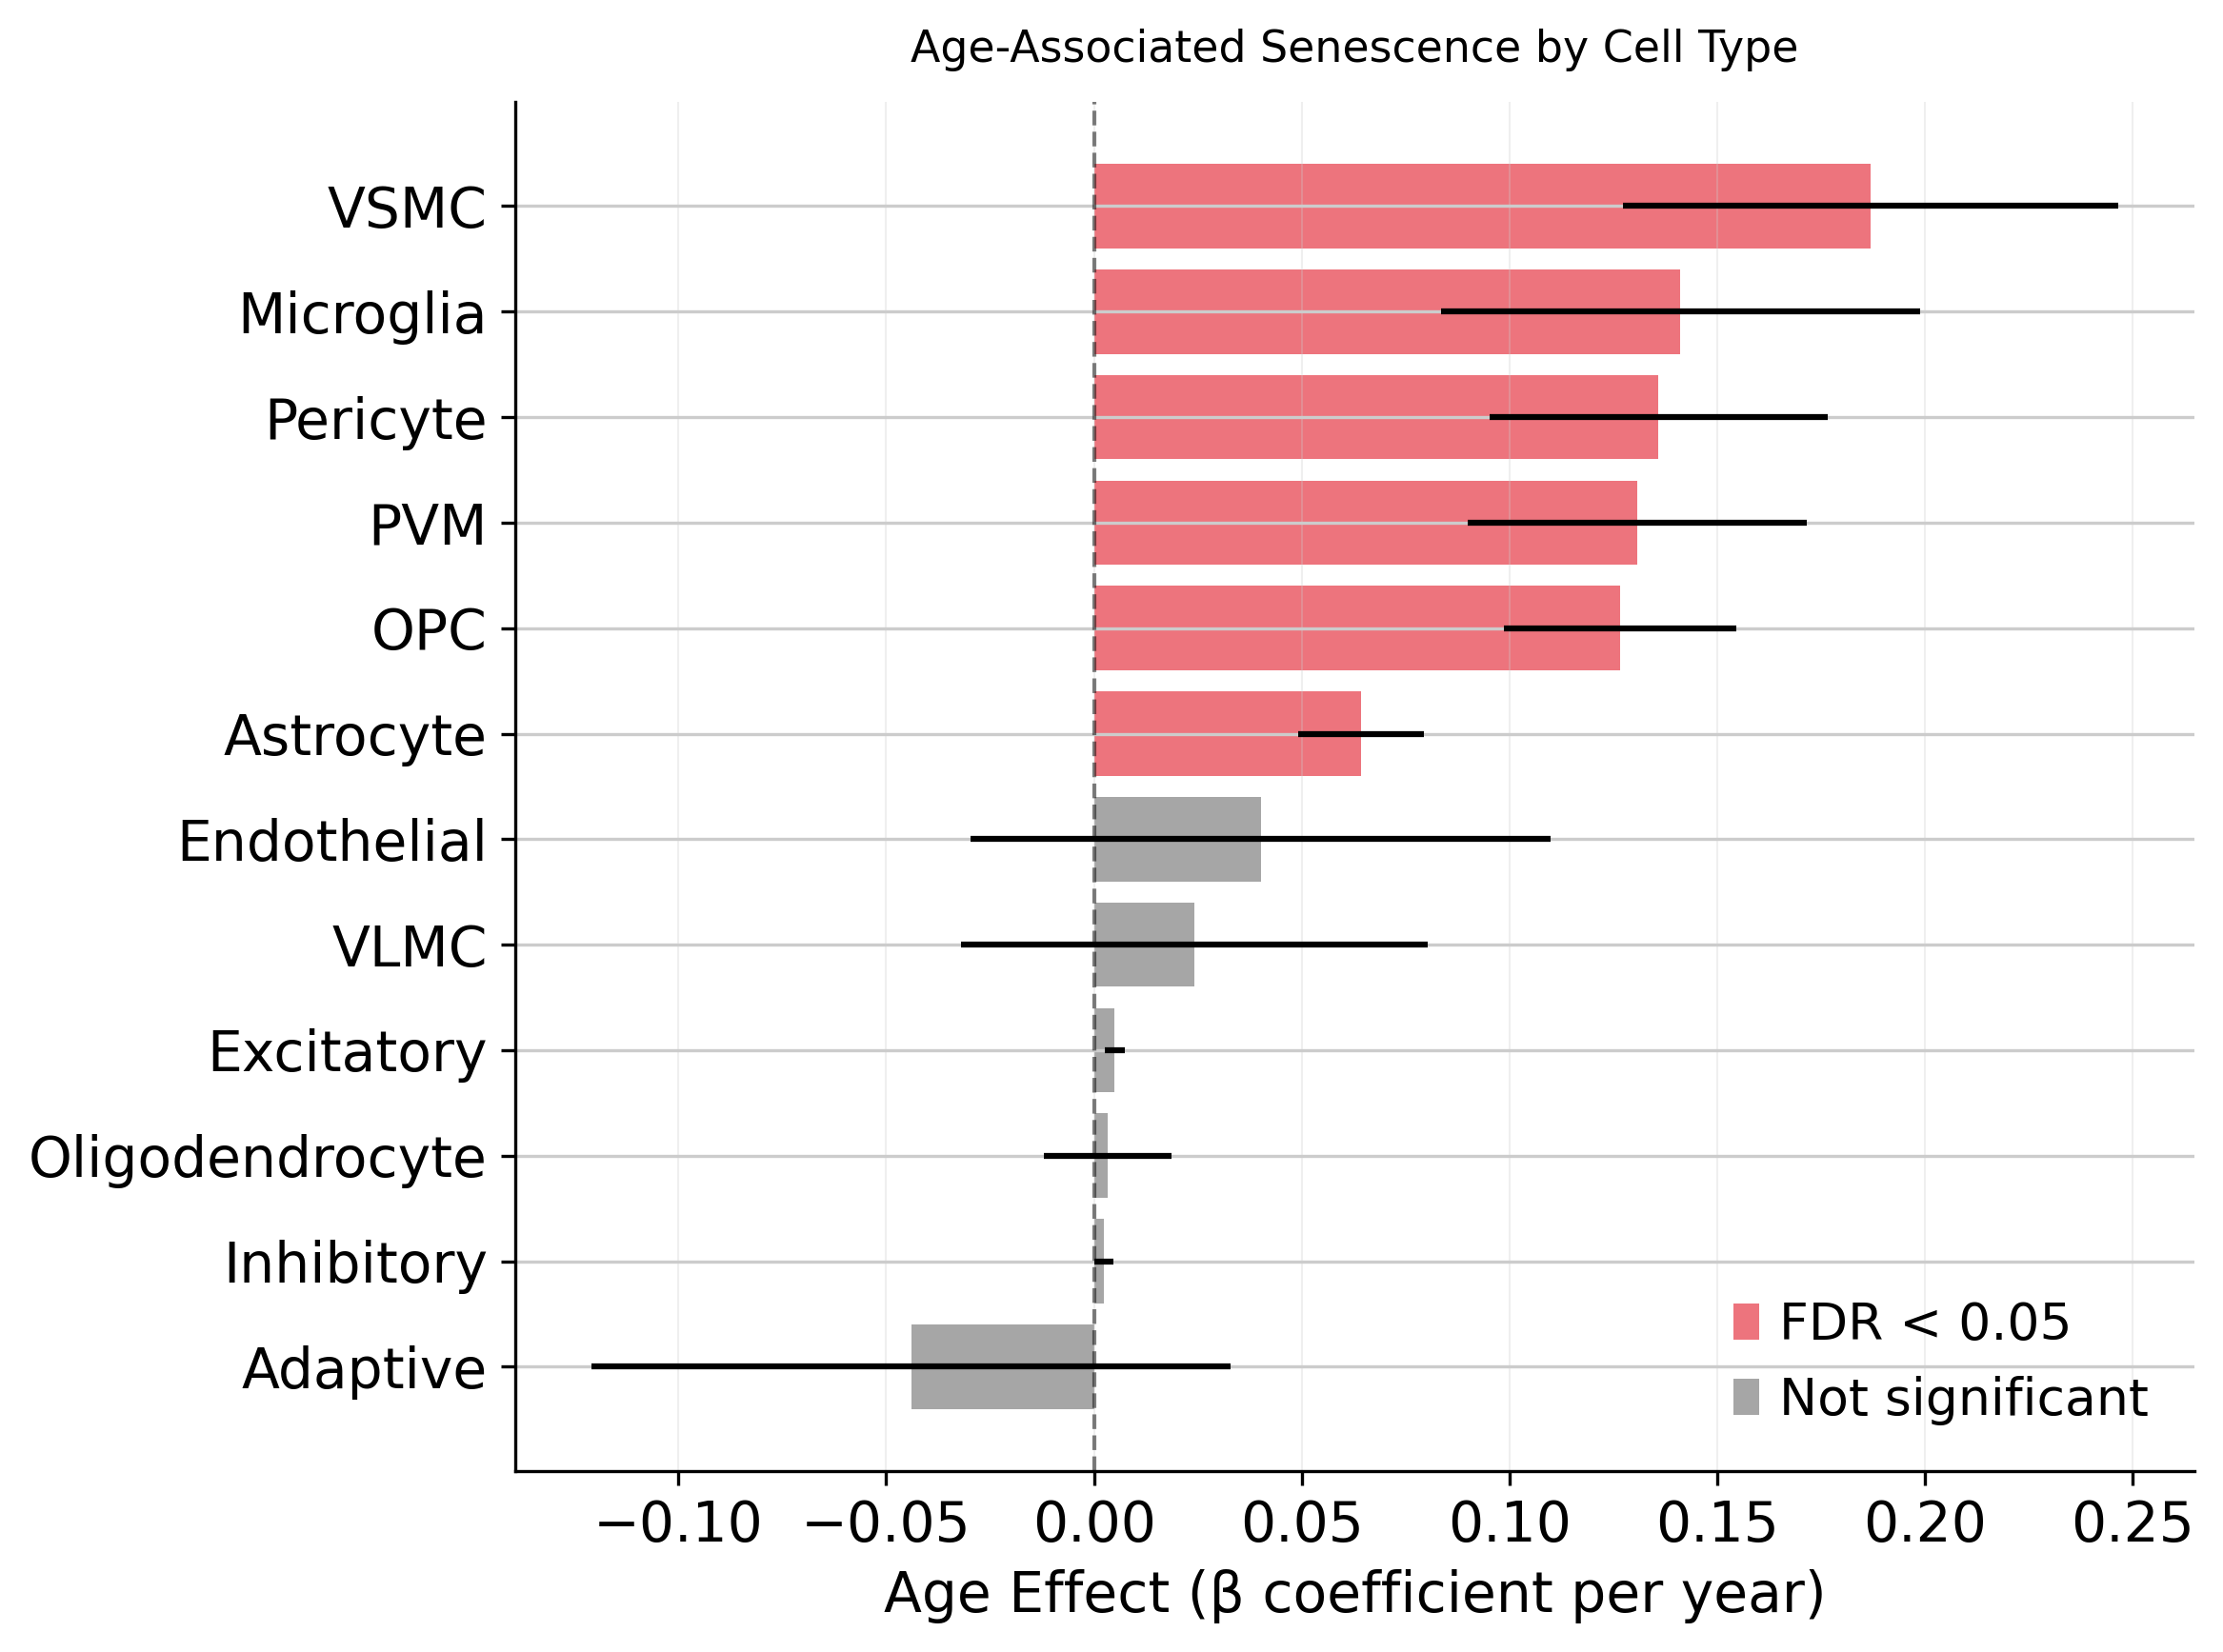

✓ Forest plot saved


In [9]:
# Forest plot showing LMM coefficients
fig, ax = plt.subplots(figsize=(8, 6))

# Sort by coefficient
df_plot = df_lmm.sort_values('Coefficient', ascending=True)

# Color by significance
colors = ['#E63946' if sig else 'gray' for sig in df_plot['Significant']]

# Plot
y_pos = range(len(df_plot))
ax.barh(y_pos, df_plot['Coefficient'], xerr=df_plot['SE'], 
        color=colors, alpha=0.7, error_kw={'linewidth': 1.5})

# Add vertical line at 0
ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Dynamic labels based on study type
if STUDY_TYPE == 'aging':
    xlabel = f'{PRIMARY_VAR} Effect (β coefficient per year)'
    title = 'Age-Associated Senescence by Cell Type'
else:
    xlabel = f'Disease Effect (β coefficient vs {config.get("reference_group", "Control")})'
    title = 'Disease-Associated Senescence by Cell Type'

# Labels
ax.set_yticks(y_pos)
ax.set_yticklabels(df_plot['Cell_Type'])
ax.set_xlabel(xlabel)
ax.set_title(title, fontsize=11, pad=10)

# Clean up
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3, linewidth=0.5)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E63946', alpha=0.7, label='FDR < 0.05'),
    Patch(facecolor='gray', alpha=0.7, label='Not significant')
]
ax.legend(handles=legend_elements, loc='lower right', frameon=False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f'{DATASET}_forest_plot.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Forest plot saved")


Creating overall SnC trend (boxplot per age with trendline)...

=== DATA CHECK ===
Age range: 20.0 - 90.0
Number of donors: 124
Ages with data: 56

Trendline model (LMM): SnC_proportion ~ Age + Sex + Cohort + (1|Donor)


/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


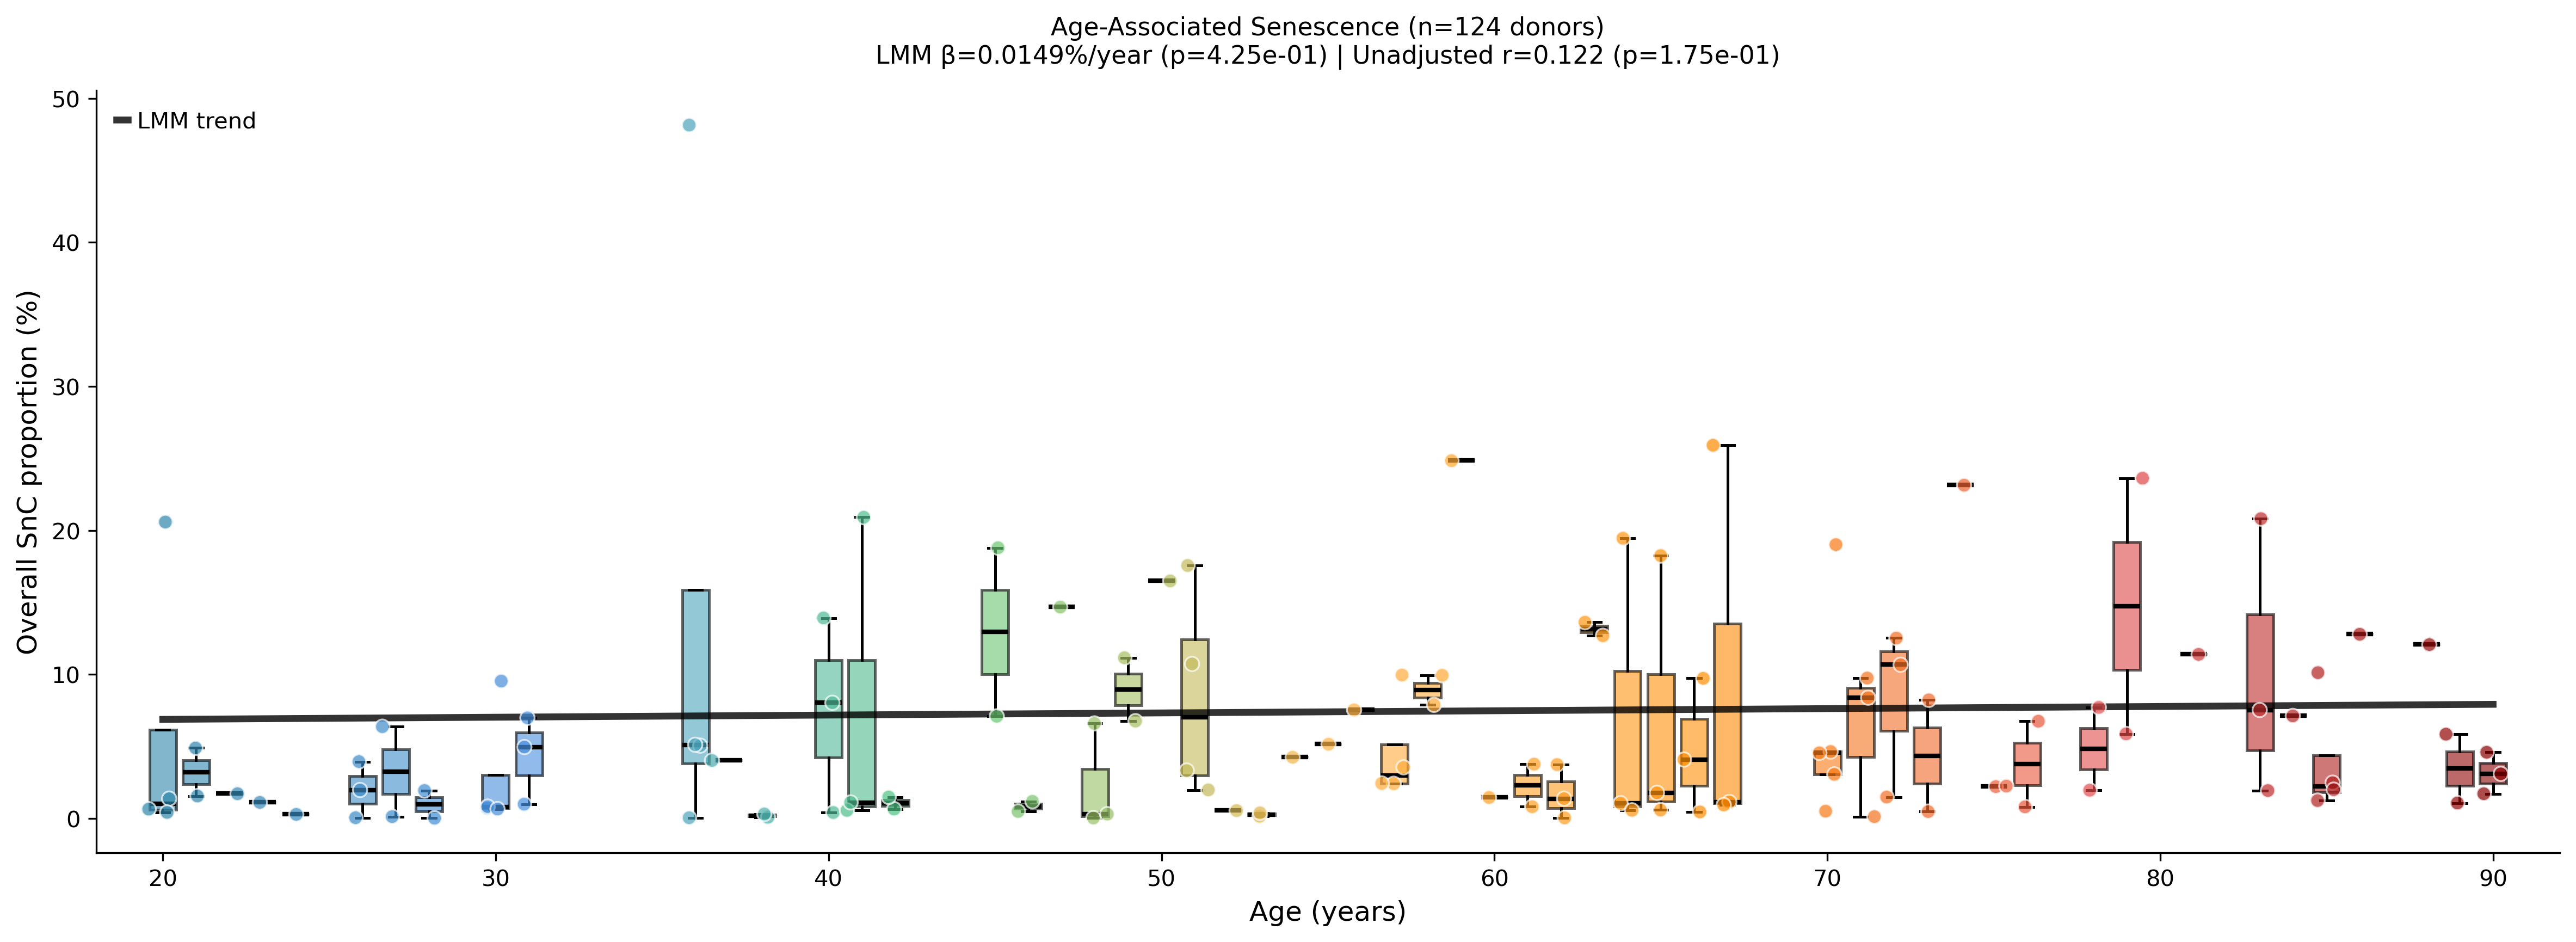

✓ Boxplot saved (ages with data: 56, full range: 20-90)
  LMM β (Age + Sex + Cohort): 0.0149
  Unadjusted r (Age only): 0.122


In [10]:
print("\nCreating overall SnC trend (boxplot per age with trendline)...")

# Calculate overall SnC proportion per donor
donor_summary = []
for donor in adata.obs[RANDOM_EFFECT].unique():
    donor_mask = adata.obs[RANDOM_EFFECT] == donor
    donor_data = adata.obs[donor_mask]
    
    n_total = len(donor_data)
    n_snc = donor_data[SENESCENCE_COLUMN].sum()
    snc_prop = (n_snc / n_total * 100) if n_total > 0 else 0
    
    donor_summary.append({
        'Donor': donor,
        PRIMARY_VAR: donor_data[PRIMARY_VAR].iloc[0],
        STUDY_GROUP_COLUMN: donor_data[STUDY_GROUP_COLUMN].iloc[0],
        'SnC_proportion': snc_prop,
        'n_cells': n_total,
    })

df_donor = pd.DataFrame(donor_summary)

# Add covariates to df_donor
for cov in COVARIATES:
    if cov not in df_donor.columns:
        # Match donors to get covariate values
        cov_map = adata.obs.groupby(RANDOM_EFFECT)[cov].first()
        df_donor[cov] = df_donor['Donor'].map(cov_map)

print(f"\n=== DATA CHECK ===")
print(f"Age range: {df_donor[PRIMARY_VAR].min():.1f} - {df_donor[PRIMARY_VAR].max():.1f}")
print(f"Number of donors: {len(df_donor)}")
print(f"Ages with data: {len(df_donor[PRIMARY_VAR].unique())}")

# ═══════════════════════════════════════════════════════════════════════════════
# AGING: BOXPLOT PER AGE WITH LMM TRENDLINE
# ═══════════════════════════════════════════════════════════════════════════════
if STUDY_TYPE == 'aging':
    from matplotlib.colors import LinearSegmentedColormap
    
    fig, ax = plt.subplots(figsize=(16, 6))
    
    # Get ages that actually have data
    ages_with_data = sorted(df_donor[PRIMARY_VAR].unique())
    
    # Create age-based color gradient (blue → red)
    min_age = 20
    max_age = 90
    
    color_list = ['#2E86AB', '#4A90E2', '#50C878', '#FFB347', '#FF8C00', '#E24A4A', '#8B0000']
    cmap = LinearSegmentedColormap.from_list('age_gradient', color_list, N=256)
    
    # Plot boxplots ONLY for ages with data
    for age in ages_with_data:
        age_data = df_donor[df_donor[PRIMARY_VAR] == age]['SnC_proportion']
        
        # Map age to color
        color_intensity = (age - min_age) / (max_age - min_age)
        box_color = cmap(color_intensity)
        
        # Create boxplot
        bp = ax.boxplot([age_data.tolist()], positions=[age], patch_artist=True,
                        showfliers=False, widths=0.8,
                        boxprops=dict(linewidth=1.2, facecolor=box_color, alpha=0.6, edgecolor='black'),
                        whiskerprops=dict(linewidth=1.2, color='black'),
                        capprops=dict(linewidth=1.2, color='black'),
                        medianprops=dict(color='black', linewidth=2))
        
        # Overlay dots with jitter
        y_values = age_data.values
        x_values = np.random.normal(age, 0.2, size=len(y_values))
        
        ax.scatter(x_values, y_values, alpha=0.7, s=40,
                  c=[box_color]*len(y_values), 
                  edgecolors='white', linewidth=0.8,
                  zorder=3)
    
    # ───────────────────────────────────────────────────────────────────────────
    # TRENDLINE: Use LMM (same model as statistical analysis)
    # ───────────────────────────────────────────────────────────────────────────
    formula_lmm = f"SnC_proportion ~ {PRIMARY_VAR}"
    for cov in COVARIATES:
        if cov in df_donor.columns:
            formula_lmm += f" + {cov}"
    
    print(f"\nTrendline model (LMM): {formula_lmm} + (1|Donor)")
    
    # Fit LMM (same as statistical analysis)
    model_lmm = mixedlm(formula_lmm, df_donor, groups=df_donor['Donor'])
    result_lmm = model_lmm.fit(reml=False)
    
    # Create prediction data (age 20-90, with mean covariates)
    x_line = np.linspace(20, 90, 100)
    pred_df = pd.DataFrame({PRIMARY_VAR: x_line})
    
    for cov in COVARIATES:
        if cov in df_donor.columns:
            # Use mode for categorical, mean for continuous
            if df_donor[cov].dtype == 'object' or df_donor[cov].dtype.name == 'category':
                pred_df[cov] = df_donor[cov].mode()[0]
            else:
                pred_df[cov] = df_donor[cov].mean()
    
    # Get fixed effects predictions (population-level)
    y_pred = result_lmm.predict(pred_df)
    
    ax.plot(x_line, y_pred, color='black', linewidth=3, 
            linestyle='-', alpha=0.8, zorder=2, label='LMM trend')
    
    # Get coefficient for Age from LMM
    age_coef = result_lmm.params[PRIMARY_VAR]
    age_pval = result_lmm.pvalues[PRIMARY_VAR]
    
    # Calculate Pearson correlation (unadjusted, for comparison)
    from scipy.stats import pearsonr
    r, r_pval = pearsonr(df_donor[PRIMARY_VAR], df_donor['SnC_proportion'])
    
    # ───────────────────────────────────────────────────────────────────────────
    # FORCE X-AXIS TO SHOW FULL RANGE 20-90
    # ───────────────────────────────────────────────────────────────────────────
    ax.set_xlim(18, 92)
    ax.set_xticks(np.arange(20, 91, 10))  # 20, 30, 40, 50, 60, 70, 80, 90
    ax.set_xticklabels(np.arange(20, 91, 10))
    
    # Labels and styling
    ax.set_xlabel('Age (years)', fontsize=12)
    ax.set_ylabel('Overall SnC proportion (%)', fontsize=12)
    ax.set_title(f'Age-Associated Senescence (n={len(df_donor)} donors)\n' + 
                f'LMM β={age_coef:.4f}%/year (p={age_pval:.2e}) | Unadjusted r={r:.3f} (p={r_pval:.2e})', 
                fontsize=11, pad=12)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=10)
    ax.grid(False)  # No grid
    ax.legend(fontsize=10, frameon=False, loc='upper left')
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'{DATASET}_overall_trend_boxplot.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Boxplot saved (ages with data: {len(ages_with_data)}, full range: 20-90)")
    print(f"  LMM β (Age + {' + '.join(COVARIATES)}): {age_coef:.4f}")
    print(f"  Unadjusted r (Age only): {r:.3f}")

# ═══════════════════════════════════════════════════════════════════════════════
# DISEASE: BOXPLOT BY DIAGNOSIS
# ═══════════════════════════════════════════════════════════════════════════════
else:
    fig, ax = plt.subplots(figsize=(7, 6))
    
    groups = sorted(df_donor[PRIMARY_VAR].unique())
    data_to_plot = [df_donor[df_donor[PRIMARY_VAR] == g]['SnC_proportion'].values for g in groups]
    colors_to_use = [STUDY_GROUP_COLORS.get(g, 'gray') for g in groups]
    
    bp = ax.boxplot(data_to_plot, labels=groups, patch_artist=True,
                   widths=0.5,
                   boxprops=dict(linewidth=1.5),
                   whiskerprops=dict(linewidth=1.5),
                   capprops=dict(linewidth=1.5),
                   medianprops=dict(color='black', linewidth=2),
                   showfliers=False)
    
    for patch, color in zip(bp['boxes'], colors_to_use):
        patch.set_facecolor(color)
        patch.set_alpha(0.3)
    
    # Overlay dots
    for j, (group, data) in enumerate(zip(groups, data_to_plot)):
        x = np.random.normal(j+1, 0.04, size=len(data))
        ax.scatter(x, data, 
                  s=50, alpha=0.6,
                  color=STUDY_GROUP_COLORS.get(group, 'gray'),
                  edgecolors='white', linewidth=0.5,
                  zorder=3)
    
    ax.set_xlabel('Diagnosis', fontsize=11)
    ax.set_ylabel('Overall SnC proportion (%)', fontsize=11)
    ax.set_title(f'Disease-Associated Senescence (n={len(df_donor)} donors)', fontsize=11, pad=10)
    ax.tick_params(labelsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'{DATASET}_overall_comparison.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Overall comparison plot saved")


Creating age trajectory plots (scatter + regression)...


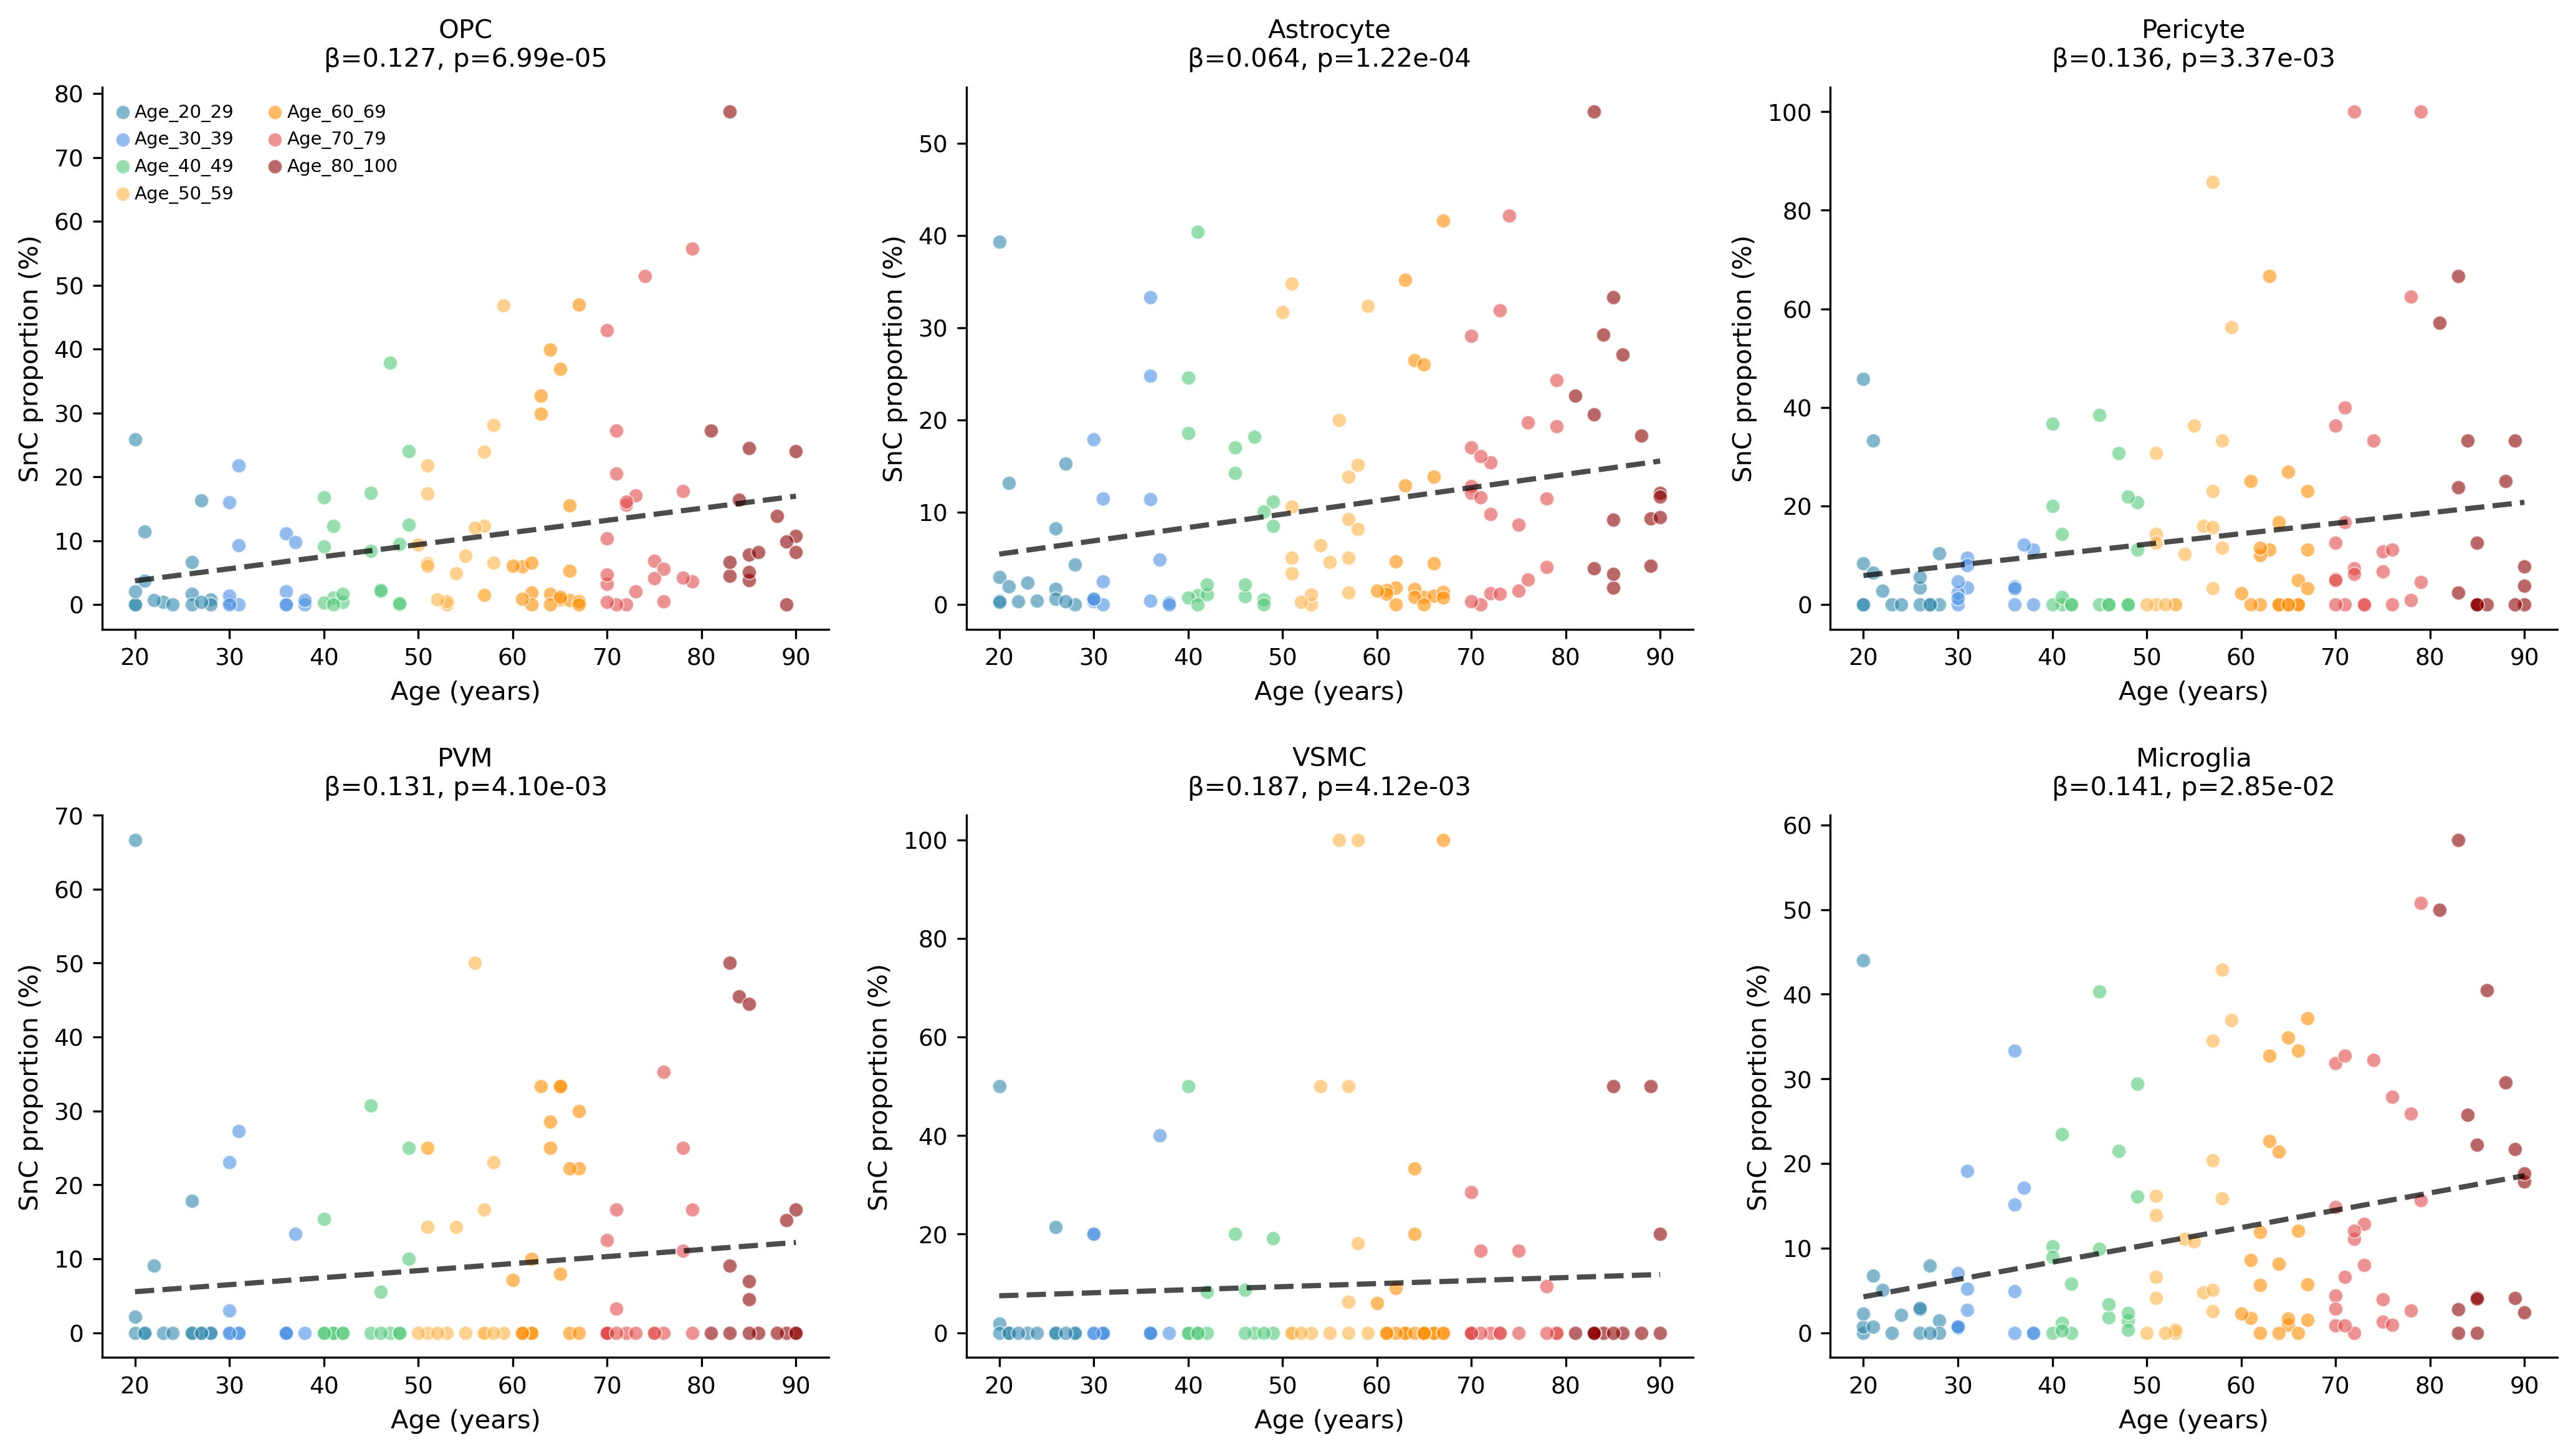

✓ Scatter trajectory plots saved


In [11]:
if STUDY_TYPE == 'aging':
    print("\nCreating age trajectory plots (scatter + regression)...")
    
    # Get top 6 significant cell types
    sig_cell_types = df_lmm[df_lmm['Significant']].sort_values('P_adj')['Cell_Type'].head(6).tolist()
    
    if len(sig_cell_types) > 0:
        fig, axes = plt.subplots(2, 3, figsize=(14, 8))
        axes = axes.flatten()
        
        for i, cell_type in enumerate(sig_cell_types):
            ax = axes[i]
            ct_data = df_agg[df_agg['Cell_Type'] == cell_type].copy()
            
            # Scatter plot - colored by age group
            for age_group in sorted(ct_data[STUDY_GROUP_COLUMN].unique()):
                group_data = ct_data[ct_data[STUDY_GROUP_COLUMN] == age_group]
                ax.scatter(group_data[PRIMARY_VAR], group_data['SnC_proportion'], 
                          s=30, alpha=0.6, 
                          color=STUDY_GROUP_COLORS.get(age_group, 'gray'),
                          label=age_group, edgecolors='white', linewidth=0.5)
            
            # Regression line
            z = np.polyfit(ct_data[PRIMARY_VAR], ct_data['SnC_proportion'], 1)
            p = np.poly1d(z)
            x_line = np.linspace(ct_data[PRIMARY_VAR].min(), ct_data[PRIMARY_VAR].max(), 100)
            ax.plot(x_line, p(x_line), color='black', linewidth=2, linestyle='--', alpha=0.7)
            
            # Get stats
            result = df_lmm[df_lmm['Cell_Type'] == cell_type].iloc[0]
            
            ax.set_xlabel('Age (years)', fontsize=10)
            ax.set_ylabel('SnC proportion (%)', fontsize=10)
            ax.set_title(f"{cell_type}\nβ={result['Coefficient']:.3f}, p={result['P_adj']:.2e}", 
                        fontsize=10, pad=8)
            
            # Clean styling - NO GRIDS
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.tick_params(labelsize=9)
            ax.grid(False)  # Remove grid
            
            # Only show legend on first plot
            if i == 0:
                ax.legend(fontsize=7, frameon=False, loc='upper left', ncol=2)
        
        # Hide unused subplots
        for i in range(len(sig_cell_types), 6):
            axes[i].set_visible(False)
        
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / f'{DATASET}_trajectories_scatter.pdf', dpi=300, bbox_inches='tight')
        plt.show()
        print("✓ Scatter trajectory plots saved")
    else:
        print("  No significant cell types to plot")
else:
    print("\n(Scatter plots only for aging cohorts)")


Creating boxplot comparisons by study group (with sample dots & trendlines)...


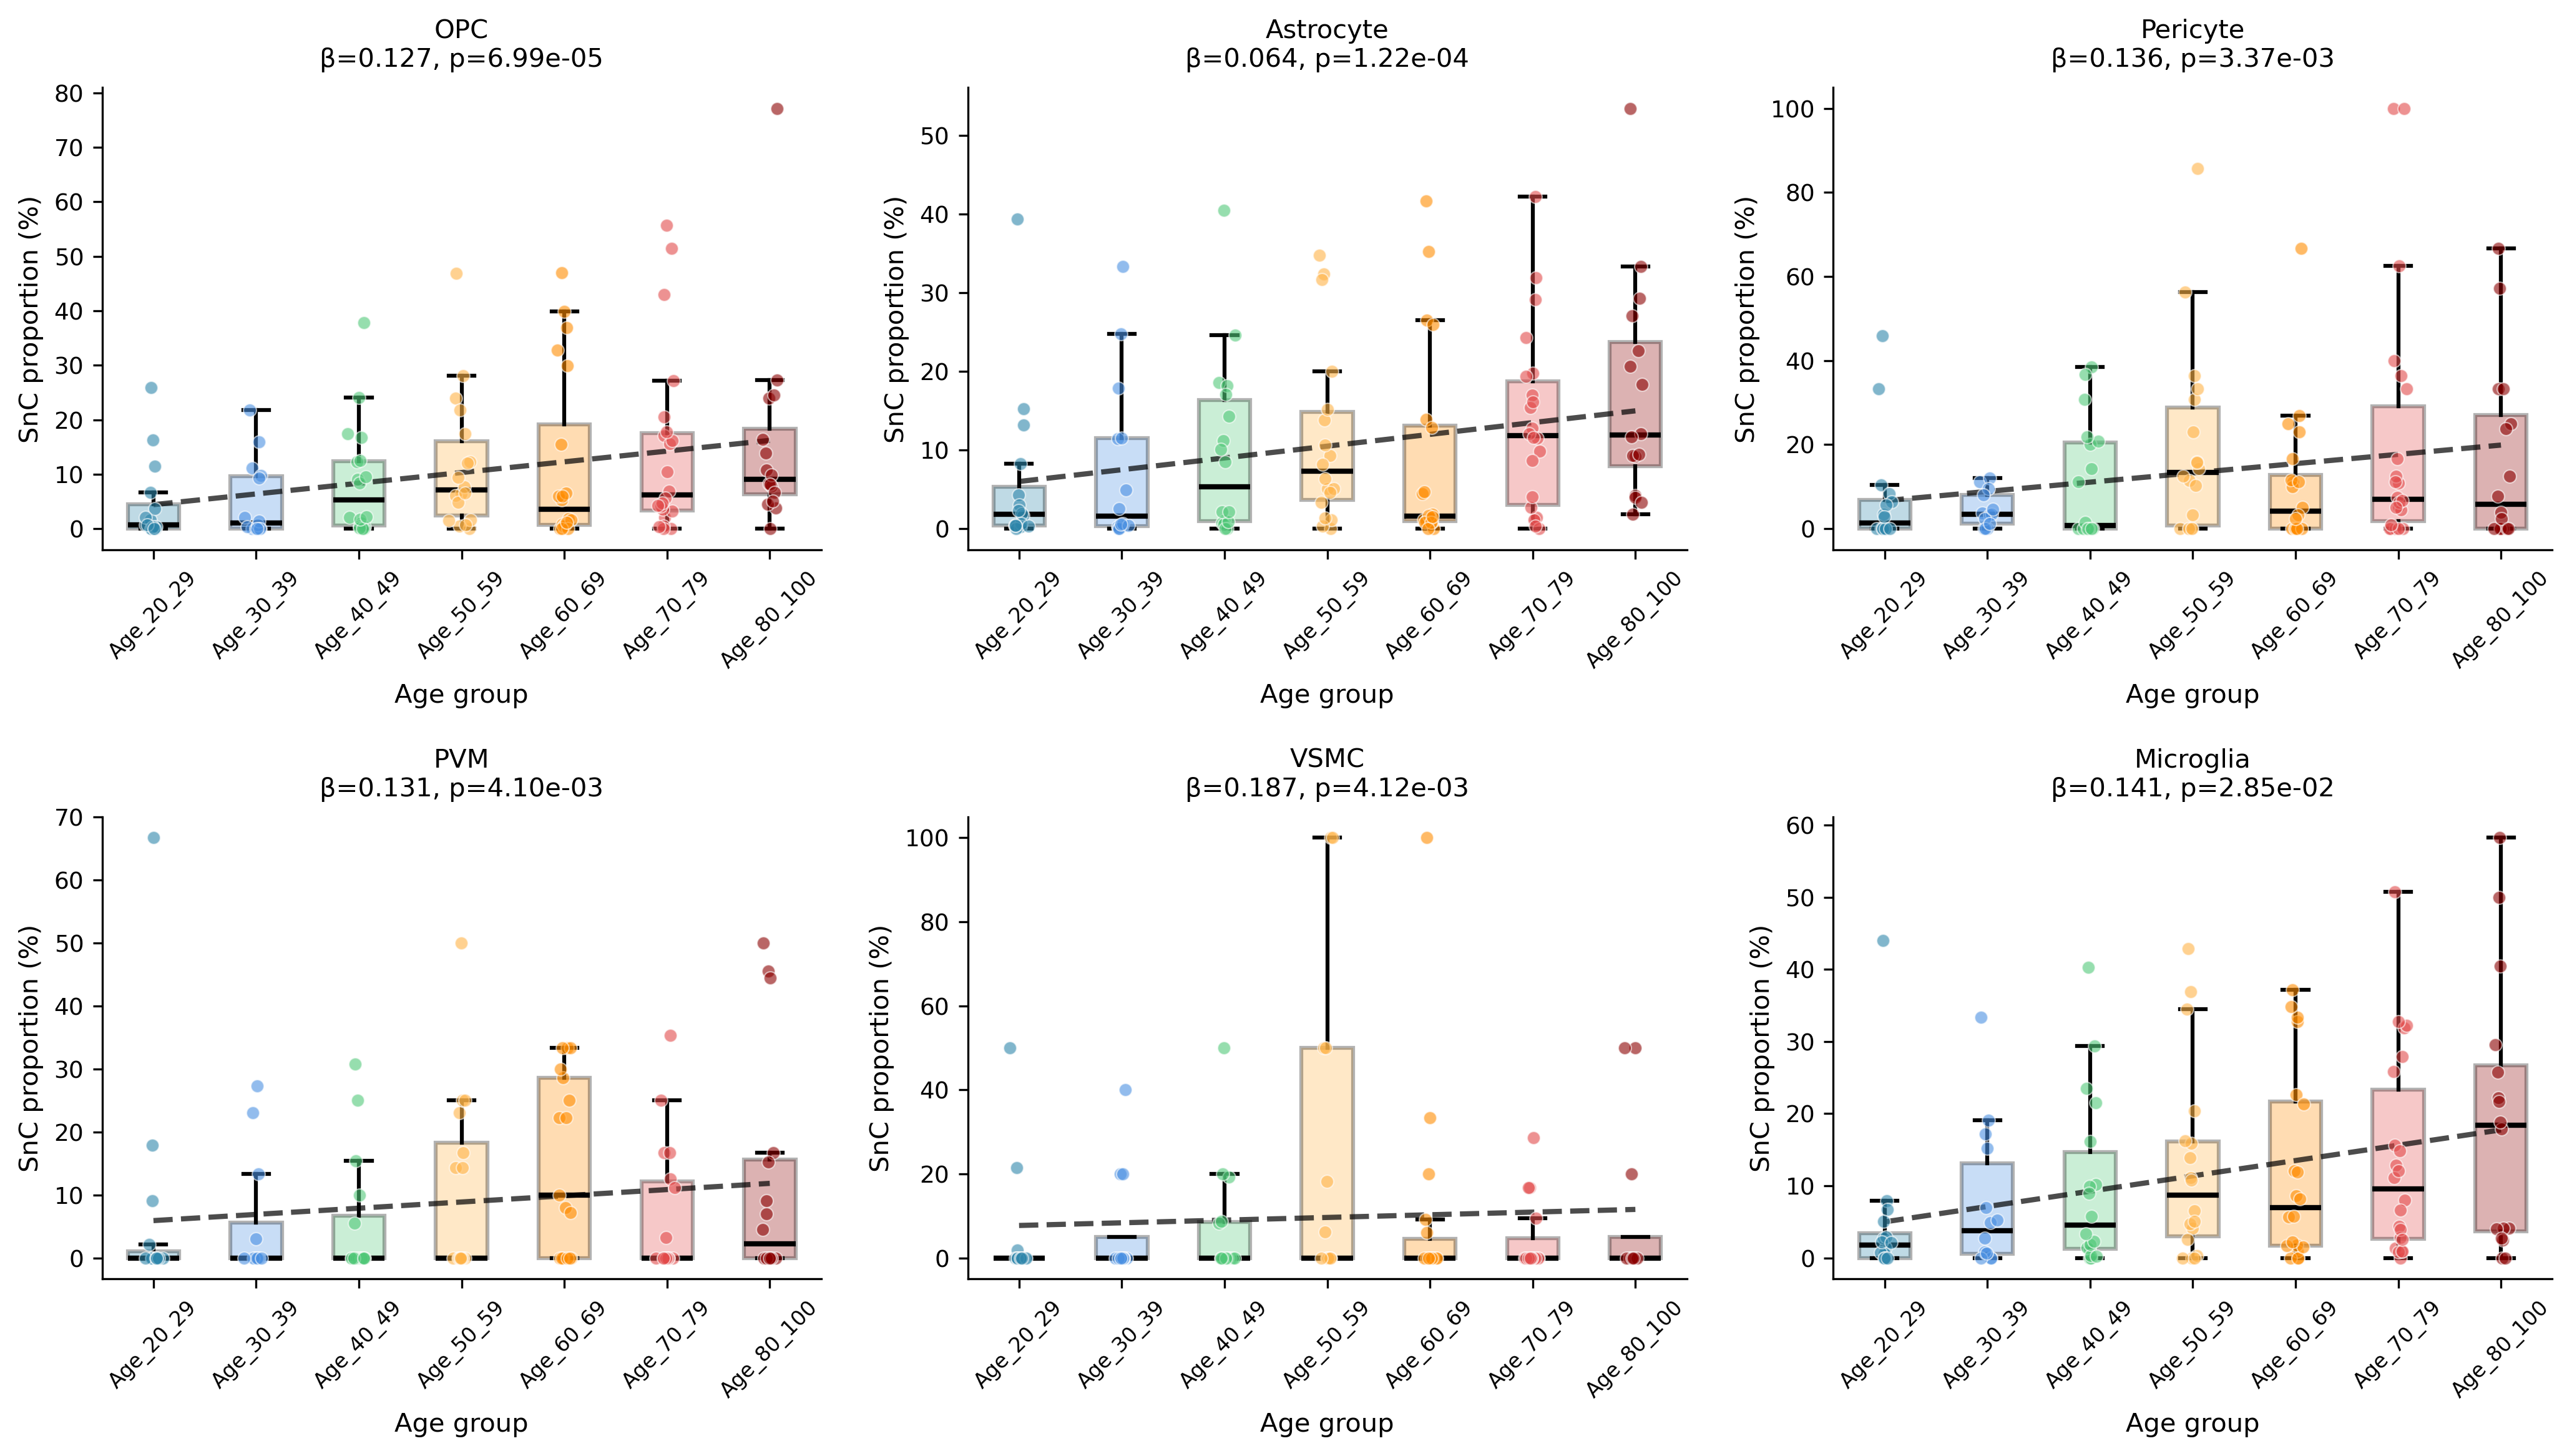

✓ Boxplot trajectory plots saved (with trendlines)


In [12]:
print("\nCreating boxplot comparisons by study group (with sample dots & trendlines)...")

# Get top 6 significant cell types
sig_cell_types = df_lmm[df_lmm['Significant']].sort_values('P_adj')['Cell_Type'].head(6).tolist()

if len(sig_cell_types) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()
    
    for i, cell_type in enumerate(sig_cell_types):
        ax = axes[i]
        ct_data = df_agg[df_agg['Cell_Type'] == cell_type].copy()
        
        # Get groups in order
        groups = sorted(ct_data[STUDY_GROUP_COLUMN].unique())
        data_to_plot = [ct_data[ct_data[STUDY_GROUP_COLUMN] == g]['SnC_proportion'].values for g in groups]
        colors_to_use = [STUDY_GROUP_COLORS.get(g, 'gray') for g in groups]
        
        # Boxplot with custom colors
        bp = ax.boxplot(data_to_plot, labels=groups, patch_artist=True,
                       widths=0.5,
                       boxprops=dict(linewidth=1.5),
                       whiskerprops=dict(linewidth=1.5),
                       capprops=dict(linewidth=1.5),
                       medianprops=dict(color='black', linewidth=2),
                       showfliers=False)
        
        # Apply colors to boxes
        for patch, color in zip(bp['boxes'], colors_to_use):
            patch.set_facecolor(color)
            patch.set_alpha(0.3)
        
        # Overlay individual sample dots
        for j, (group, data) in enumerate(zip(groups, data_to_plot)):
            x = np.random.normal(j+1, 0.04, size=len(data))
            ax.scatter(x, data, 
                      s=25, alpha=0.6,
                      color=STUDY_GROUP_COLORS.get(group, 'gray'),
                      edgecolors='white', linewidth=0.5,
                      zorder=3)
        
        # ───────────────────────────────────────────────────────────────────────
        # ADD TRENDLINE (for aging cohorts)
        # ───────────────────────────────────────────────────────────────────────
        if STUDY_TYPE == 'aging' and PRIMARY_VAR in ct_data.columns:
            # Use actual age values (not group positions) for trendline
            ages = ct_data[PRIMARY_VAR].values
            proportions = ct_data['SnC_proportion'].values
            
            # Fit linear regression
            z = np.polyfit(ages, proportions, 1)
            p = np.poly1d(z)
            
            # Map age groups to their x-positions for plotting
            age_group_positions = {group: j+1 for j, group in enumerate(groups)}
            
            # Create smooth line across group positions
            x_positions = np.linspace(1, len(groups), 100)
            
            # Map positions back to ages for prediction
            # Get mean age for each group
            group_to_age = ct_data.groupby(STUDY_GROUP_COLUMN)[PRIMARY_VAR].mean().to_dict()
            age_range = [group_to_age[groups[0]], group_to_age[groups[-1]]]
            ages_line = np.linspace(age_range[0], age_range[1], 100)
            y_line = p(ages_line)
            
            ax.plot(x_positions, y_line, color='black', linewidth=2, 
                   linestyle='--', alpha=0.7, zorder=2)
        
        # Get stats
        result = df_lmm[df_lmm['Cell_Type'] == cell_type].iloc[0]
        
        # Labels
        if STUDY_TYPE == 'aging':
            ax.set_xlabel('Age group', fontsize=10)
        else:
            ax.set_xlabel('Diagnosis', fontsize=10)
        
        ax.set_ylabel('SnC proportion (%)', fontsize=10)
        ax.set_title(f"{cell_type}\nβ={result['Coefficient']:.3f}, p={result['P_adj']:.2e}", 
                    fontsize=10, pad=8)
        
        # Rotate x-labels for readability
        ax.tick_params(axis='x', rotation=45, labelsize=8)
        ax.tick_params(axis='y', labelsize=9)
        
        # Clean styling - NO GRIDS
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(False)  # Remove grid
    
    # Hide unused subplots
    for i in range(len(sig_cell_types), 6):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'{DATASET}_trajectories_boxplot.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Boxplot trajectory plots saved (with trendlines)")
else:
    print("  No significant cell types to plot")

---

## Sex Interaction Analysis

Test if primary variable effect differs between males and females.

**Aging:** Does age-associated senescence differ by sex?  
**Disease:** Does disease-associated senescence differ by sex?

In [13]:
print("\n" + "="*80)
print("SEX INTERACTION ANALYSIS")
print("="*80)

if STUDY_TYPE == 'aging' and 'Sex' in df_agg.columns:
    print("\nTesting Age × Sex interaction per cell type...")
    
    sex_interaction_results = []
    
    for cell_type in sorted(df_agg['Cell_Type'].unique()):
        ct_data = df_agg[df_agg['Cell_Type'] == cell_type].copy()
        
        if len(ct_data) < 10:
            continue
        
        try:
            # Model with interaction
            formula_interaction = f"SnC_proportion ~ {PRIMARY_VAR} * Sex"
            if 'Cohort' in ct_data.columns:
                formula_interaction += " + Cohort"
            
            model = mixedlm(formula_interaction, ct_data, groups=ct_data['Donor'])
            result = model.fit(reml=False)
            
            # Get interaction term
            interaction_param = f"{PRIMARY_VAR}:Sex[T.Male]" if f"{PRIMARY_VAR}:Sex[T.Male]" in result.params.index else None
            
            if interaction_param:
                interaction_coef = result.params[interaction_param]
                interaction_pval = result.pvalues[interaction_param]
                
                sex_interaction_results.append({
                    'Cell_Type': cell_type,
                    'Interaction_Coef': interaction_coef,
                    'P_value': interaction_pval,
                })
                
                print(f"  {cell_type}: Interaction β={interaction_coef:.4f}, p={interaction_pval:.2e}")
            
        except Exception as e:
            print(f"  {cell_type}: Failed ({str(e)[:50]})")
    
    if len(sex_interaction_results) > 0:
        df_sex_int = pd.DataFrame(sex_interaction_results)
        df_sex_int['P_adj'] = multipletests(df_sex_int['P_value'], method='fdr_bh')[1]
        df_sex_int['Significant'] = df_sex_int['P_adj'] < 0.05
        
        # Save results
        sex_results_file = RESULTS_DIR / f'{DATASET}_sex_interaction_results.csv'
        df_sex_int.to_csv(sex_results_file, index=False)
        
        print(f"\n✓ Sex interaction analysis complete")
        print(f"\nSignificant sex interactions (FDR < 0.05):")
        sig_sex = df_sex_int[df_sex_int['Significant']].sort_values('P_adj')
        if len(sig_sex) > 0:
            for _, row in sig_sex.iterrows():
                print(f"  {row['Cell_Type']}: β={row['Interaction_Coef']:.4f}, p_adj={row['P_adj']:.2e}")
        else:
            print("  None - age effects are similar between sexes")
    else:
        print("\n⚠ No cell types analyzed for sex interaction")
        
else:
    print("\n(Sex interaction analysis only for aging cohorts with Sex variable)")


SEX INTERACTION ANALYSIS

Testing Age × Sex interaction per cell type...
  Adaptive: Interaction β=0.0919, p=5.53e-01
  Astrocyte: Interaction β=-0.0207, p=8.36e-01
  Endothelial: Interaction β=-0.0416, p=7.06e-01
  Excitatory: Interaction β=-0.0023, p=8.65e-01


/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not 

  Inhibitory: Interaction β=-0.0060, p=3.38e-01
  Microglia: Interaction β=-0.1571, p=1.47e-02
  OPC: Interaction β=0.0189, p=8.67e-01
  Oligodendrocyte: Interaction β=0.0317, p=1.98e-01
  PVM: Interaction β=-0.1389, p=2.50e-01


/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not 

  Pericyte: Interaction β=-0.0914, p=5.88e-01
  VLMC: Interaction β=-0.1165, p=1.40e-01
  VSMC: Interaction β=-0.1632, p=3.56e-02

✓ Sex interaction analysis complete

Significant sex interactions (FDR < 0.05):
  None - age effects are similar between sexes


/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


---

## Cell Type Composition Analysis

Test if cell type proportions change with primary variable.

**Method:** Cube root transformation for proportions, LMM with donor random effects.

In [14]:
print("\n" + "="*80)
print("CELL TYPE COMPOSITION ANALYSIS")
print("="*80)

print("\nCalculating cell type proportions per donor...")

# Calculate cell type composition per donor
composition_data = []

for donor in adata.obs[RANDOM_EFFECT].unique():
    donor_mask = adata.obs[RANDOM_EFFECT] == donor
    donor_data = adata.obs[donor_mask]
    
    donor_age = donor_data[PRIMARY_VAR].iloc[0]
    donor_study_group = donor_data[STUDY_GROUP_COLUMN].iloc[0]
    
    # Get covariates
    donor_covariates = {}
    for cov in COVARIATES:
        if cov in donor_data.columns:
            donor_covariates[cov] = donor_data[cov].iloc[0]
    
    total_cells = len(donor_data)
    
    # Calculate proportion for each cell type
    for cell_type in donor_data[CELL_TYPE_COLUMN].unique():
        ct_count = (donor_data[CELL_TYPE_COLUMN] == cell_type).sum()
        ct_prop = (ct_count / total_cells * 100) if total_cells > 0 else 0
        
        # Cube root transformation for variance stabilization
        ct_prop_cuberoot = (ct_prop / 100) ** (1/3)
        
        row = {
            'Donor': donor,
            'Cell_Type': cell_type,
            'n_cells': ct_count,
            'Cell_Type_Proportion': ct_prop,
            'Proportion_CubeRoot': ct_prop_cuberoot,  # Transformed for analysis
            PRIMARY_VAR: donor_age,
            STUDY_GROUP_COLUMN: donor_study_group,
        }
        row.update(donor_covariates)  # Add Sex, Cohort, etc.
        composition_data.append(row)

df_comp = pd.DataFrame(composition_data)

print(f"✓ Composition calculated")
print(f"  Observations: {len(df_comp):,} (donor × cell type)")

# Run LMM for each cell type using CUBE ROOT TRANSFORMED proportions
print(f"\nTesting composition ~ {PRIMARY_VAR} per cell type...")
print(f"  Transformation: (proportion/100)^(1/3)")
print(f"  Covariates: {', '.join(COVARIATES)}")

comp_results = []

for cell_type in sorted(df_comp['Cell_Type'].unique()):
    ct_data = df_comp[df_comp['Cell_Type'] == cell_type].copy()
    
    if len(ct_data) < 10:
        continue
    
    try:
        # Build formula with CUBE ROOT transformed proportions + ALL COVARIATES
        formula_comp = f"Proportion_CubeRoot ~ {PRIMARY_VAR}"
        for cov in COVARIATES:
            if cov in ct_data.columns and cov != PRIMARY_VAR:
                formula_comp += f" + {cov}"
        
        # Print formula for first cell type to verify
        if cell_type == sorted(df_comp['Cell_Type'].unique())[0]:
            print(f"\n  Model: {formula_comp} + (1|Donor)")
        
        model = mixedlm(formula_comp, ct_data, groups=ct_data['Donor'])
        result = model.fit(reml=False)
        
        coef = result.params[PRIMARY_VAR]
        pval = result.pvalues[PRIMARY_VAR]
        
        comp_results.append({
            'Cell_Type': cell_type,
            'Coefficient': coef,
            'P_value': pval,
        })
        
        print(f"  {cell_type}: β={coef:.4f}, p={pval:.2e}")
        
    except Exception as e:
        print(f"  {cell_type}: Failed - {str(e)[:50]}")

if len(comp_results) > 0:
    df_comp_results = pd.DataFrame(comp_results)
    df_comp_results['P_adj'] = multipletests(df_comp_results['P_value'], method='fdr_bh')[1]
    df_comp_results['Significant'] = df_comp_results['P_adj'] < 0.05
    
    # Save
    comp_file = RESULTS_DIR / f'{DATASET}_composition_results.csv'
    df_comp_results.to_csv(comp_file, index=False)
    
    print(f"\n✓ Composition analysis complete")
    print(f"  Formula: Proportion_CubeRoot^(1/3) ~ {PRIMARY_VAR} + {' + '.join(COVARIATES)} + (1|Donor)")
    print(f"\nSignificant composition changes (FDR < 0.05):")
    sig_comp = df_comp_results[df_comp_results['Significant']].sort_values('P_adj')
    if len(sig_comp) > 0:
        for _, row in sig_comp.iterrows():
            direction = "increases" if row['Coefficient'] > 0 else "decreases"
            print(f"  {row['Cell_Type']}: {direction} with {PRIMARY_VAR} (β={row['Coefficient']:.4f}, p_adj={row['P_adj']:.2e})")
    else:
        print(f"  None - cell type proportions stable with {PRIMARY_VAR}")


CELL TYPE COMPOSITION ANALYSIS

Calculating cell type proportions per donor...
✓ Composition calculated
  Observations: 1,419 (donor × cell type)

Testing composition ~ Age per cell type...
  Transformation: (proportion/100)^(1/3)
  Covariates: Sex, Cohort

  Model: Proportion_CubeRoot ~ Age + Sex + Cohort + (1|Donor)
  Adaptive: β=-0.0003, p=2.89e-06
  Astrocyte: β=-0.0005, p=2.90e-03
  Endothelial: β=-0.0006, p=1.68e-02
  Excitatory: β=0.0005, p=4.63e-01


/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, Converge

  Inhibitory: β=-0.0003, p=1.82e-01
  Microglia: β=-0.0004, p=6.05e-03
  OPC: β=-0.0014, p=1.58e-04
  Oligodendrocyte: β=0.0017, p=1.65e-02
  PVM: β=-0.0002, p=3.44e-01


/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, Converge

  Pericyte: β=-0.0004, p=9.28e-02
  VLMC: β=-0.0001, p=4.95e-01
  VSMC: β=0.0000, p=7.14e-01

✓ Composition analysis complete
  Formula: Proportion_CubeRoot^(1/3) ~ Age + Sex + Cohort + (1|Donor)

Significant composition changes (FDR < 0.05):
  Adaptive: decreases with Age (β=-0.0003, p_adj=3.47e-05)
  OPC: decreases with Age (β=-0.0014, p_adj=9.49e-04)
  Astrocyte: decreases with Age (β=-0.0005, p_adj=1.16e-02)
  Microglia: decreases with Age (β=-0.0004, p_adj=1.81e-02)
  Endothelial: decreases with Age (β=-0.0006, p_adj=3.35e-02)
  Oligodendrocyte: increases with Age (β=0.0017, p_adj=3.35e-02)


/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, Converge

---

## Summary

Module 02 complete: Statistical analysis of age-associated senescence.

In [15]:
print("\n" + "="*80)
print("✓ MODULE 02 COMPLETE: STATISTICAL ANALYSIS")
print("="*80)

print(f"\nDataset: {DATASET}")
print(f"Study type: {STUDY_TYPE}")
print(f"Primary variable: {PRIMARY_VAR}")

print(f"\n{'='*80}")
print("ANALYSES PERFORMED")
print(f"{'='*80}")

print(f"\n1. PRIMARY ANALYSIS:")
print(f"   Model: Linear Mixed-Effects Model (LMM)")
print(f"   Formula: SnC_proportion ~ {PRIMARY_VAR} + {' + '.join(COVARIATES)} + (1|Donor)")
print(f"   Cell types analyzed: {len(df_lmm)}")
print(f"   Significant associations (FDR < 0.05): {df_lmm['Significant'].sum()}")
if df_lmm['Significant'].sum() > 0:
    print(f"\n   Significant cell types:")
    for _, row in df_lmm[df_lmm['Significant']].sort_values('P_adj').iterrows():
        print(f"     • {row['Cell_Type']}: β={row['Coefficient']:.4f}, p_adj={row['P_adj']:.2e}")

if 'df_sex_int' in locals():
    print(f"\n2. SEX INTERACTION ANALYSIS:")
    print(f"   Model: LMM with Age × Sex interaction")
    print(f"   Cell types analyzed: {len(df_sex_int)}")
    print(f"   Significant interactions (FDR < 0.05): {df_sex_int['Significant'].sum()}")
    if df_sex_int['Significant'].sum() > 0:
        for _, row in df_sex_int[df_sex_int['Significant']].iterrows():
            print(f"     • {row['Cell_Type']}: β={row['Interaction_Coef']:.4f}")
    else:
        print(f"     → Age effects similar between sexes")

if 'df_comp_results' in locals():
    print(f"\n3. CELL TYPE COMPOSITION ANALYSIS:")
    print(f"   Model: LMM with cube root transformed proportions")
    print(f"   Transformation: (proportion/100)^(1/3)")
    print(f"   Cell types analyzed: {len(df_comp_results)}")
    print(f"   Significant changes (FDR < 0.05): {df_comp_results['Significant'].sum()}")
    if df_comp_results['Significant'].sum() > 0:
        print(f"\n   Cell types with composition changes:")
        for _, row in df_comp_results[df_comp_results['Significant']].sort_values('P_adj').iterrows():
            direction = "↑ increases" if row['Coefficient'] > 0 else "↓ decreases"
            print(f"     • {row['Cell_Type']}: {direction} (β={row['Coefficient']:.4f})")

print(f"\n{'='*80}")
print("OUTPUT FILES")
print(f"{'='*80}")

print(f"\nResults (CSV):")
print(f"  • {RESULTS_DIR / f'{DATASET}_lmm_results.csv'}")
if 'df_sex_int' in locals():
    print(f"  • {RESULTS_DIR / f'{DATASET}_sex_interaction_results.csv'}")
if 'df_comp_results' in locals():
    print(f"  • {RESULTS_DIR / f'{DATASET}_composition_results.csv'}")

print(f"\nFigures (PDF):")
print(f"  • {FIGURES_DIR / f'{DATASET}_forest_plot.pdf'}")
print(f"  • {FIGURES_DIR / f'{DATASET}_overall_trend_boxplot.pdf'}")
print(f"  • {FIGURES_DIR / f'{DATASET}_trajectories_scatter.pdf'}")
print(f"  • {FIGURES_DIR / f'{DATASET}_trajectories_boxplot.pdf'}")

print(f"\n{'='*80}")
print("STATISTICAL METHODS")
print(f"{'='*80}")
print(f"\n• Linear Mixed-Effects Models (LMM) with donor random effects")
print(f"• Multiple testing correction: FDR (Benjamini-Hochberg)")
print(f"• Visualization: LMM fixed effects predictions")
print(f"• Composition analysis: Cube root transformation")

# Get statsmodels version correctly
import statsmodels
print(f"• Software: statsmodels {statsmodels.__version__}")

print("\n" + "="*80)
print("✓ Ready for Module 03 (Disease/Meta-analysis) or Module 04 (Differential Expression)")
print("="*80)


✓ MODULE 02 COMPLETE: STATISTICAL ANALYSIS

Dataset: psychad_aging
Study type: aging
Primary variable: Age

ANALYSES PERFORMED

1. PRIMARY ANALYSIS:
   Model: Linear Mixed-Effects Model (LMM)
   Formula: SnC_proportion ~ Age + Sex + Cohort + (1|Donor)
   Cell types analyzed: 12
   Significant associations (FDR < 0.05): 6

   Significant cell types:
     • OPC: β=0.1267, p_adj=6.99e-05
     • Astrocyte: β=0.0643, p_adj=1.22e-04
     • Pericyte: β=0.1358, p_adj=3.37e-03
     • PVM: β=0.1307, p_adj=4.10e-03
     • VSMC: β=0.1869, p_adj=4.12e-03
     • Microglia: β=0.1412, p_adj=2.85e-02

2. SEX INTERACTION ANALYSIS:
   Model: LMM with Age × Sex interaction
   Cell types analyzed: 12
   Significant interactions (FDR < 0.05): 0
     → Age effects similar between sexes

3. CELL TYPE COMPOSITION ANALYSIS:
   Model: LMM with cube root transformed proportions
   Transformation: (proportion/100)^(1/3)
   Cell types analyzed: 12
   Significant changes (FDR < 0.05): 6

   Cell types with composit